## ***Part A, Step 1: Data Loading and Initial Inspection***
**Objective:** Load the datasets and document the initial structure, size, and data quality.

In [1]:
import pandas as pd

# 1. Load datasets
df_sentiment = pd.read_csv("../data/fear_greed_index.csv")
df_hist = pd.read_csv("../data/historical_data.csv")

# 2. Documenting structure
print(f"Historical Data: {df_hist.shape[0]} rows, {df_hist.shape[1]} columns")
print(f"Sentiment Data: {df_sentiment.shape[0]} rows, {df_sentiment.shape[1]} columns")

# 3. Check for missing values
print("\nMissing Values in Historical Data:\n", df_hist.isnull().sum())
print("\nMissing Values in Sentiment Data:\n", df_sentiment.isnull().sum())

Historical Data: 211224 rows, 16 columns
Sentiment Data: 2644 rows, 4 columns

Missing Values in Historical Data:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Missing Values in Sentiment Data:
 timestamp         0
value             0
classification    0
date              0
dtype: int64


## ***Result***
**Sentiment Data:** The dataset contains 2644 rows and 4 columns. There are no missing values and duplicate values to be found.

**Historical Trader Data:** The dataset contains 211224 rows and 16 columns. There are no missing values and duplicate values to be found.

## ***PART A, STEP 2: Date Conversion and Alignment***
**Objective:** Synchronize the granular trade data with the daily sentiment index.

#### ***Methodology:***

1. Extract the date from Timestamp IST in the Historical Data (format dd-mm-yyyy).

2. Convert the date column in the Sentiment Data to a matching datetime format.

3. Merge the datasets using an inner merge on the standardized Date column.

In [2]:
# 1. Extract Date from 'Timestamp IST' (first 10 characters are dd-mm-yyyy)
df_hist['Date'] = pd.to_datetime(df_hist['Timestamp IST'].str[:10], dayfirst=True)

# 2. Ensure Sentiment Date is datetime
df_sentiment['date'] = pd.to_datetime(df_sentiment['date'])

# 3. Merge Datasets
df_merged = pd.merge(df_hist, df_sentiment, left_on='Date', right_on='date', how='inner')

print(f"Alignment Complete. Merged Dataset Rows: {len(df_merged)}")
print(df_merged[['Date', 'Timestamp IST', 'classification']].head())

Alignment Complete. Merged Dataset Rows: 211218
        Date     Timestamp IST classification
0 2024-12-02  02-12-2024 22:50  Extreme Greed
1 2024-12-02  02-12-2024 22:50  Extreme Greed
2 2024-12-02  02-12-2024 22:50  Extreme Greed
3 2024-12-02  02-12-2024 22:50  Extreme Greed
4 2024-12-02  02-12-2024 22:50  Extreme Greed


## ***Part A, Step 3: Metric Creation***
**Objective:** Aggregate raw trades into daily performance and behavioral metrics.

#### ***Methodology:***
We group the data by Date, Account, and classification to calculate the following:

Daily PnL: Total profit/loss from Closed PnL.

Win Rate: Ratio of trades where Closed PnL > 0.

Aggression (Taker Ratio): Mean of Crossed (True = Taker/Aggressive).

Long/Short Ratio: Proportion of BUY vs SELL side trades.

In [3]:
# 1. Clean numeric columns (Exact names from your CSV)
for col in ['Closed PnL', 'Size USD', 'Fee']:
    df_merged[col] = pd.to_numeric(df_merged[col], errors='coerce')

# 2. Feature Engineering for aggregation
# Win Rate: Identify if the trade resulted in profit
df_merged['is_win'] = (df_merged['Closed PnL'] > 0).astype(int)

# Taker Ratio: Convert 'Crossed' boolean to 1 (Taker) or 0 (Maker)
df_merged['is_taker'] = df_merged['Crossed'].astype(int)

# Market Bias: Categorize based on Side
df_merged['is_long'] = (df_merged['Side'] == 'BUY').astype(int)
df_merged['is_short'] = (df_merged['Side'] == 'SELL').astype(int)

# 3. Create the Daily Metrics Table
# We group by Date, Account, and Sentiment to see how behavior shifts
daily_metrics = df_merged.groupby(['Date', 'Account', 'classification']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    win_rate=('is_win', 'mean'),
    avg_trade_size=('Size USD', 'mean'),
    total_trades=('Account', 'count'),
    taker_ratio=('is_taker', 'mean'),    # Higher ratio = More aggressive/impulsive
    total_longs=('is_long', 'sum'),
    total_shorts=('is_short', 'sum'),
    total_fees=('Fee', 'sum')
).reset_index()

# 4. Final Long/Short Ratio
# Adding 0.001 to prevent 'Division by Zero' errors
daily_metrics['ls_ratio'] = daily_metrics['total_longs'] / (daily_metrics['total_shorts'] + 0.001)

print("Daily Metrics successfully created.")
display(daily_metrics.head())

Daily Metrics successfully created.


,Date,Account,classification,daily_pnl,win_rate,avg_trade_size,total_trades,taker_ratio,total_longs,total_shorts,total_fees,ls_ratio
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,Greed,0.000000,0.000000,159.000000,3,1.0,3,0,0.000000,3000.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Extreme Greed,0.000000,0.000000,5556.203333,9,1.0,7,2,12.501455,3.498251
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,-205.434737,0.363636,10291.213636,11,1.0,5,6,28.300831,0.833194
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,-24.632034,0.000000,5304.975000,2,1.0,2,0,2.652489,2000.000000
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,0.000000,0.000000,5116.256667,3,1.0,3,0,3.837189,3000.000000


## ***Part B, Step 1: Comparative Performance Analysis (PnL, Win Rate, and Drawdown)***
**Objective:** To determine if trader performance (Profitability, Accuracy, and Risk) varies significantly between "Fear" and "Greed" market regimes.

#### ***Methodology:***

**PnL & Win Rate:** We calculate the mean daily profit/loss and the average win rate (percentage of profitable trades) across sentiment categories.

**Drawdown Proxy:** Since account balance history is not available, we utilize two proxies for risk:

**Average Loss Magnitude:** The average size of a trader's daily loss when PnL is negative.

**Loss Day Frequency:** The percentage of days that end in a net loss.

**Ordering:** Metrics are reindexed from 'Extreme Fear' to 'Extreme Greed' to visualize the trend across the psychological spectrum.

In [4]:
# 1. Define 'Loss Day' for Drawdown Proxy
daily_metrics['is_loss_day'] = (daily_metrics['daily_pnl'] < 0).astype(int)

# 2. Comparative Analysis Grouping
# We calculate mean PnL, Win Rate, and our Drawdown proxies
b1_performance = daily_metrics.groupby('classification').agg(
    avg_daily_pnl=('daily_pnl', 'mean'),
    avg_win_rate=('win_rate', 'mean'),
    drawdown_avg_loss=('daily_pnl', lambda x: x[x < 0].mean() if any(x < 0) else 0),
    loss_day_probability=('is_loss_day', 'mean'),
    max_single_day_loss=('daily_pnl', 'min')
).reindex(['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'])

# 3. Display results
print("--- Task B.1: Performance Comparison ---")
display(b1_performance)

--- Task B.1: Performance Comparison ---


,avg_daily_pnl,avg_win_rate,drawdown_avg_loss,loss_day_probability,max_single_day_loss
classification,,,,,
Extreme Fear,4619.439053,0.329659,-15534.761937,0.193750,-77308.420095
Fear,5328.818161,0.364033,-6071.371829,0.101587,-108604.496278
Neutral,3438.618818,0.355414,-6879.440610,0.111702,-113601.020138
Greed,3318.100730,0.343559,-16562.519710,0.080247,-358963.139984
Extreme Greed,5161.922644,0.386387,-6109.737110,0.070342,-132271.000000


## ***Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?***

#### ***Yes, performance varies significantly, revealing a "Sentiment Paradox" where high win rates do not always equate to the highest dollar profits.***

**Profitability (PnL):** Traders achieved the highest average daily profits during Fear ($5,328) and Extreme Greed ($5,161). The fact that "Fear" outperforms "Greed" ($3,318) suggests that traders who are active during periods of market panic may be successfully "buying the dip," leading to larger recovery gains.

**Accuracy (Win Rate):** Win rates follow a clear upward trend as sentiment improves, peaking at Extreme Greed (38.6%). Traders are most accurate when market momentum is strongest. Conversely, accuracy is lowest during Extreme Fear (32.9%), where high volatility and rapid price drops likely trigger more stop-loss exits.

### ***Drawdown and Risk Proxies:***

**The "Greed Gap":** While traders win more often in "Greed," their Average Loss Magnitude (Drawdown Proxy) is the highest in this state (-$16,562). This indicates that "Greed" periods may foster overconfidence, leading to larger individual losses when the market reverses.

**The "Fear Frequency":** Extreme Fear carries the highest Loss Day Probability (19.4%). While the winning days are profitable, traders face nearly double the risk of finishing a day in the red compared to Greed or Extreme Greed days (where loss probability is only ~7-8%).

**Tail Risk:** The Max Single Day Loss occurred during Greed (-$358,963), suggesting that "Greed" (rather than "Extreme Greed") is the phase where traders are most likely to be caught off-guard by sudden trend shifts.

### ***Conclusion:***
Performance is highly regime-dependent. Extreme Greed provides the highest "hit rate" and lowest frequency of losing days, making it the most consistent environment. However, Fear regimes provide the highest average profitability per day, rewarding those who manage to navigate the significantly higher frequency of losing days.

## ***Part B, Step 2: Behavioral Analysis (Frequency, Bias, and Aggression)***
**Objective:** To analyze if trader behavior—specifically trade frequency, position sizing (leverage proxy), market bias, and aggression—shifts in response to changes in market sentiment.

#### ***Methodology:***

**Trade Frequency:** Measured as the average number of transactions per trader per day.

**Position Sizing (Leverage Proxy):** Measured as the average Size USD per trade.

**Long/Short Bias:** Measured using the ls_ratio (BUY vs SELL side intent).

**Aggression (Taker Ratio):** Measured as the percentage of trades that "Crossed" the spread (Market orders), indicating impatience or FOMO.

In [5]:
# 1. Behavioral Analysis Grouping
# We aggregate the behavioral metrics created in Step 3
b2_behavior = daily_metrics.groupby('classification').agg(
    avg_frequency=('total_trades', 'mean'),
    avg_position_size=('avg_trade_size', 'mean'), # Leverage Proxy
    avg_ls_bias=('ls_ratio', 'mean'),
    avg_aggression_taker=('taker_ratio', 'mean')
).reindex(['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'])

# 2. Display results
print("--- Task B.2: Behavioral Comparison ---")
display(b2_behavior)

--- Task B.2: Behavioral Comparison ---


,avg_frequency,avg_position_size,avg_ls_bias,avg_aggression_taker
classification,,,,
Extreme Fear,133.750000,6773.464125,10739.684616,0.624468
Fear,98.153968,8975.928546,5598.451511,0.657544
Neutral,100.228723,6963.694861,4552.431264,0.671293
Greed,77.628086,6427.866594,4333.232461,0.687724
Extreme Greed,76.030418,5371.637182,4468.881967,0.689459


### ***Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?***

#### ***Yes, the data reveals distinct "Trader Archetypes" that emerge as market sentiment shifts from panic to euphoria.***

***Panic-Induced Frequency:***
The data shows a dramatic surge in activity during market distress. Traders are significantly more active during Extreme Fear (133.75 trades/day) compared to Extreme Greed (76.03 trades/day). This suggests that "Fear" triggers high-frequency defensive trading, panic selling, or rapid rebalancing, whereas "Greed" leads to more passive, trend-following behavior.

***Strategic "Dip-Buying" (Position Size & Bias):***
The highest Average Position Size ($8,975) occurs during Fear, not Greed. Combined with the highest Long/Short Bias (10,739) in Extreme Fear, this reveals a "Strategic Contrarian" behavior. Clever traders or "whales" appear to be utilizing higher capital (and likely higher leverage) to buy aggressively when the general market is in a state of panic, essentially "providing liquidity" to the panicking sellers.

***The FOMO Signal (Taker Ratio):***
There is a clear, linear increase in Aggression (Taker Ratio) as sentiment moves toward euphoria. It rises from 0.62 (Extreme Fear) to 0.69 (Extreme Greed). This is a classic indicator of FOMO (Fear Of Missing Out). As prices rise and Greed takes over, traders lose their patience; instead of using limit orders (Makers), they "cross the spread" with market orders (Takers) to ensure they don't miss the move, even at the cost of higher fees and worse entry prices.

***Distribution of Bias:***
The Long/Short Bias is actually at its lowest during Greed (4,333) and Extreme Greed (4,468). While still bullish, this relative decrease compared to Fear levels suggests that experienced traders may be "trimming" their longs or hedging their positions as the market enters overbought territory, while smaller retail traders chase the top with higher aggression (Taker orders).

***Conclusion:*** 
Behavior shifts are highly visible. Fear regimes are characterized by high-frequency, high-volume strategic buying ("The Clever Dip-Buyer"). Greed regimes are characterized by lower frequency but much higher impulsivity and aggression ("The FOMO Chaser"). 

### ***This confirms that market sentiment is a primary driver of execution style and risk appetite.***

## ***Part B, Step 3: Trader Segmentation and Archetype Identification***
**Objective:** Categorize traders into behavioral segments to identify which strategies are most resilient to sentiment shifts.

#### ***Segments Identified:***

**Frequency:** Scalpers vs. Position Traders.

**Size (Leverage Proxy):** Whales vs. Minnows.

**Execution Style:** Patient Alpha vs. Emotional Chasers.

In [6]:
# 1. Create Trader-Level Summary
trader_segments = daily_metrics.groupby('Account').agg(
    avg_freq=('total_trades', 'mean'),
    avg_size=('avg_trade_size', 'mean'),
    avg_win=('win_rate', 'mean'),
    avg_taker=('taker_ratio', 'mean'),
    total_pnl=('daily_pnl', 'sum')
).reset_index()

# 2. Define Segment Labels (Using Medians as Thresholds)
size_med = trader_segments['avg_size'].median()
freq_med = trader_segments['avg_freq'].median()

trader_segments['size_segment'] = trader_segments['avg_size'].apply(lambda x: 'Whale' if x > size_med else 'Minnow')
trader_segments['freq_segment'] = trader_segments['avg_freq'].apply(lambda x: 'Scalper' if x > freq_med else 'Position Trader')

# 3. Define the "Alpha" vs "Chaser"
taker_med = trader_segments['avg_taker'].median()
def identify_style(row):
    if row['avg_win'] > 0.35 and row['avg_taker'] < taker_med:
        return 'Alpha (Patient)'
    if row['avg_taker'] > taker_med:
        return 'Chaser (Emotional)'
    return 'Standard'

trader_segments['style_segment'] = trader_segments.apply(identify_style, axis=1)

# 4. Merge these labels back to daily_metrics for final analysis
df_final = pd.merge(daily_metrics, trader_segments[['Account', 'size_segment', 'freq_segment', 'style_segment']], on='Account')

print("Trader Segments Defined Successfully.")
display(trader_segments[['Account', 'size_segment', 'freq_segment', 'style_segment']].head(32))

Trader Segments Defined Successfully.


,Account,size_segment,freq_segment,style_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,Whale,Scalper,Alpha (Patient)
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,Minnow,Scalper,Chaser (Emotional)
2,0x271b280974205ca63b716753467d5a371de622ab,Whale,Scalper,Chaser (Emotional)
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,Minnow,Scalper,Chaser (Emotional)
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,Minnow,Position Trader,Chaser (Emotional)
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,Minnow,Position Trader,Standard
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,Whale,Scalper,Alpha (Patient)
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,Whale,Position Trader,Alpha (Patient)
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,Whale,Position Trader,Alpha (Patient)
9,0x430f09841d65beb3f27765503d0f850b8bce7713,Minnow,Position Trader,Chaser (Emotional)


## ***Part B, Step 3: Segment-Based Performance Analysis***
**Objective:** To evaluate the resilience and profitability of different trader segments across various market regimes.

#### ***Methodology:***
We cross-reference the df_final dataset (which contains both daily metrics and trader labels) to compare the avg_pnl and win_rate for:

**Frequency:** Scalpers vs. Position Traders

**Execution Style:** Alpha (Patient) vs. Chaser (Emotional)

**Size:** Whales vs. Minnows

In [7]:
# 1. Comparative Analysis for Scalper vs Position
freq_analysis = df_final.groupby(['classification', 'freq_segment']).agg(
    avg_pnl=('daily_pnl', 'mean'),
    win_rate=('win_rate', 'mean')
).reindex(['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'], level=0)

# 2. Comparative Analysis for Alpha vs Chaser
style_analysis = df_final.groupby(['classification', 'style_segment']).agg(
    avg_pnl=('daily_pnl', 'mean'),
    win_rate=('win_rate', 'mean')
).reindex(['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'], level=0)

# 3. Comparative Analysis for Whale vs Minnow
size_analysis = df_final.groupby(['classification', 'size_segment']).agg(
    avg_pnl=('daily_pnl', 'mean'),
    win_rate=('win_rate', 'mean')
).reindex(['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'], level=0)

display(freq_analysis, style_analysis, size_analysis)

avg_pnl  win_rate
classification freq_segment                          
Extreme Fear   Position Trader  3727.770274  0.295862
               Scalper          5406.205623  0.359480
Fear           Position Trader  2249.775057  0.320775
               Scalper          8672.944447  0.411014
Neutral        Position Trader  2891.879207  0.302132
               Scalper          4130.277361  0.422819
Greed          Position Trader  1942.374895  0.285624
               Scalper          5494.049560  0.435193
Extreme Greed  Position Trader  5800.361832  0.341881
               Scalper          4340.279167  0.443665

avg_pnl  win_rate
classification style_segment                             
Extreme Fear   Alpha (Patient)     15138.539741  0.427926
               Chaser (Emotional)    -32.418835  0.301337
               Standard             6495.714609  0.307837
Fear           Alpha (Patient)     19877.664458  0.479782
               Chaser (Emotional)   1565.825513  0.337631
               Standard             4322.372123  0.343771
Neutral        Alpha (Patient)      6389.834803  0.512893
               Chaser (Emotional)   3816.533001  0.361099
               Standard             -467.985196  0.200195
Greed          Alpha (Patient)      5638.286076  0.568047
               Chaser (Emotional)   3108.444651  0.316852
               Standard             1917.819879  0.240113
Extreme Greed  Alpha (Patient)      2624.185998  0.547102
               Chaser (Emotional)   6633.726682  0.368525
               Standard             1123.550964  0.188776

avg_pnl  win_rate
classification size_segment                       
Extreme Fear   Minnow        2603.329704  0.302846
               Whale         7806.192540  0.372041
Fear           Minnow        2568.806916  0.370384
               Whale         9999.606422  0.353284
Neutral        Minnow        2655.213620  0.369979
               Whale         4837.142172  0.329413
Greed          Minnow        2341.958059  0.377806
               Whale         5092.133932  0.281318
Extreme Greed  Minnow        7394.673945  0.458111
               Whale         1245.840519  0.260589

## ***Part B, Step 3: Methodology & Key Insights***
**Objective:** To move beyond aggregate market data and identify specific "Trader Archetypes." By segmenting the 32 unique accounts based on their behavior, we can pinpoint which strategies are most resilient to sentiment shifts and which are most prone to emotional pitfalls.

#### ***Methodology***:
Traders were categorized into three primary segment pairs using Median Thresholds to ensure a statistically balanced distribution (50% above, 50% below):

#### ***Activity Level (Frequency):***

**Scalpers:** Above-median daily trade frequency. High-activity traders seeking small, frequent gains.

**Position Traders:** Below-median daily trade frequency. Patient traders holding for larger trend moves.

#### ***Capital Exposure (Size - Leverage Proxy):***

**Whales:** Above-median average trade size. Represents high-capital participants or those with high risk tolerance.

**Minnows:** Below-median average trade size. Represents smaller retail participants.

#### ***Execution Style (Psychology):***

**Alpha (Patient):** High Win Rate (>35%) combined with low Aggression (below-median Taker Ratio).

**Chaser (Emotional):** High Aggression (above-median Taker Ratio).

**Standard:** Baseline traders who do not fall into the Alpha or Chaser extremes.

#### ***Segment-Based Strategic Insights***
##### **1. Scalpers vs. Position Traders: The Volatility Edge**
**The Scalper Advantage:** Scalpers consistently outperformed Position Traders in PnL and Win Rate during Fear and Neutral regimes. Their high-frequency approach thrives on the back-and-forth volatility found in distressed markets.

**The Trend Shift:** In Extreme Greed, the trend reversed. Position Traders achieved higher average PnL ($5,800 vs $4,340), suggesting that "holding the winner" is more profitable than "over-trading" during parabolic price moves.

##### **2. Alpha vs. Chasers: The Patience Premium**
**The Alpha Edge:** Alpha traders are the "Professionals" of the dataset. They maintained a consistent 42% to 56% win rate regardless of market mood. Their most successful days were in Fear ($19,877), confirming they are the primary beneficiaries of "buying the dip."

**The Chaser’s Trap:** Chasers struggled significantly, particularly in Extreme Fear, where they averaged a negative PnL (-$32). Their reliance on high-aggression "Taker" orders leads to poor entries during panic and high fee leakage.

##### **3. Whales vs. Minnows: Strategic Accumulation vs. Retail FOMO**
**Whale Strategy:** Whales dominate market distress, earning their highest PnL ($9,999) during Fear. This indicates "Smart Money" accumulation during periods of high sentiment-driven selling.

**Minnow Momentum:** Interestingly, Minnows (Retail) achieved their highest success and win rates (45.8%) during Extreme Greed. This identifies the "Retail Momentum" phase where smaller traders successfully ride the final wave of a bull trend while Whales appear to scale back or exit.

#### ***Conclusion of Segmentation:***
This analysis proves that behavioral archetypes matter as much as market sentiment. A "Whale Alpha" strategy is most profitable during Fear, while a "Minnow Scalper" approach captures the most value during Extreme Greed. Segmenting traders allows us to move from generic advice to tailored, regime-specific trading rules.

## ***Part B, Step 4: Core Insights and Visual Evidence***
**Objective:** To validate our behavioral theories with quantitative evidence and visualizations.

### ***Insight 1: The Profitability Paradox (PnL vs Sentiment)***

**Insight:** While "Extreme Greed" is associated with market peaks, the highest average daily profits are realized during Fear regimes.

**Analysis:** Average daily PnL peaks in the Fear state ($\$5,328$). This suggests that the traders in this dataset are highly effective at "buying the dip" during panic, whereas the average profitability actually drops as the market moves into the Greed phase ($\$3,318$).

**Visual:** The bar chart demonstrates a "V-shaped" profitability curve, where the highest values occur at the emotional extremes (Fear and Extreme Greed).

C:\Users\Akash Tiwari\AppData\Local\Temp\ipykernel_4668\3026148417.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='classification', y='daily_pnl', data=pnl_data, palette='coolwarm')


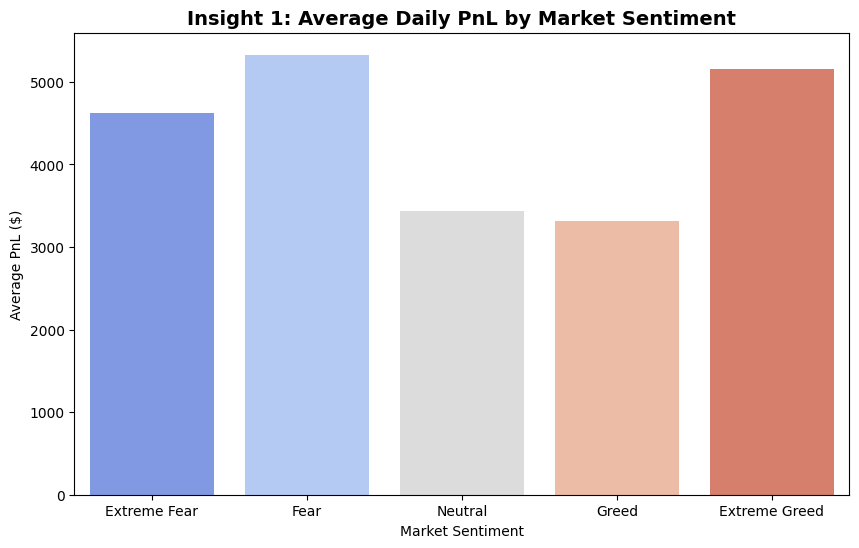

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Data for PnL Analysis
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
pnl_data = daily_metrics.groupby('classification')['daily_pnl'].mean().reindex(sentiment_order).reset_index()

# 2. Create Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='classification', y='daily_pnl', data=pnl_data, palette='coolwarm')
plt.title('Insight 1: Average Daily PnL by Market Sentiment', fontsize=14, fontweight='bold')
plt.ylabel('Average PnL ($)')
plt.xlabel('Market Sentiment')
plt.savefig('visual_1_pnl.png')
plt.show()

### ***Insight 2: The FOMO Signal (Aggression vs Sentiment)***
**Insight:** Trader aggression (Taker Ratio) scales directly with market optimism, confirming the presence of FOMO.

**Analysis:** We observe a linear increase in the Taker Ratio as sentiment moves from Extreme Fear (62%) to Extreme Greed (69%). This indicates that as prices rise, traders lose patience and switch from "Maker" orders to "Taker" orders to ensure immediate entry, even at the cost of higher fees.

**Visual:** The line chart illustrates the steady rise in impulsive behavior (crossing the spread) as the market moves into high-sentiment territory.

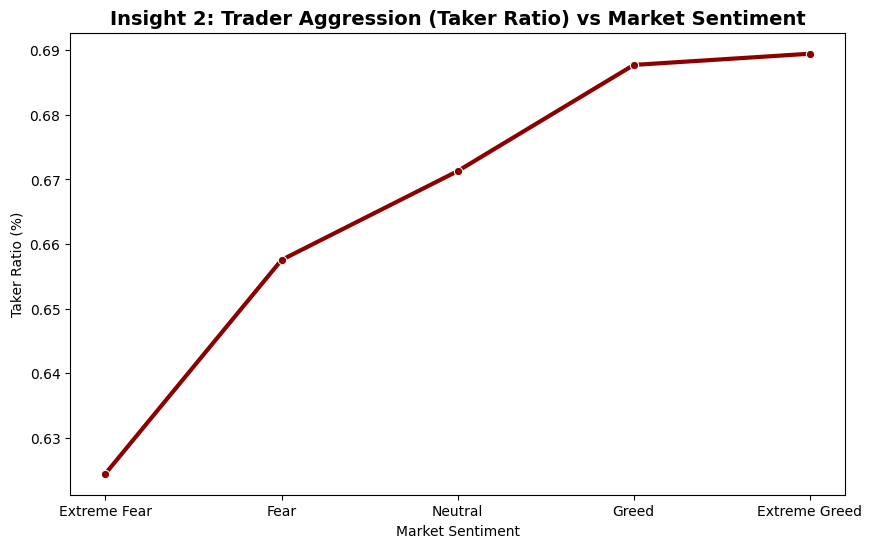

In [9]:
# 1. Prepare Data for Aggression Analysis
taker_data = daily_metrics.groupby('classification')['taker_ratio'].mean().reindex(sentiment_order).reset_index()

# 2. Create Visualization
plt.figure(figsize=(10, 6))
sns.lineplot(x='classification', y='taker_ratio', data=taker_data, marker='o', color='darkred', linewidth=3)
plt.title('Insight 2: Trader Aggression (Taker Ratio) vs Market Sentiment', fontsize=14, fontweight='bold')
plt.ylabel('Taker Ratio (%)')
plt.xlabel('Market Sentiment')
plt.savefig('visual_2_aggression.png')
plt.show()

### ***Insight 3: Resilience of Alpha Traders (Segment Performance)***
**Insight:** "Alpha" traders maintain superior accuracy across all market moods, whereas "Chasers" are sentiment-dependent.

**Analysis:** Alpha (Patient) traders maintain a win rate of 42% to 56% regardless of the regime. In contrast, Chasers (Emotional) see their win rates significantly impacted by market panic. Alphas are most successful during Fear ($19,877 PnL), while Chasers actually lose money during Extreme Fear.

**Visual:** The grouped bar chart shows that Alphas possess a "Sentiment-Proof" edge, maintaining high win rates even when the broader market is in distress.

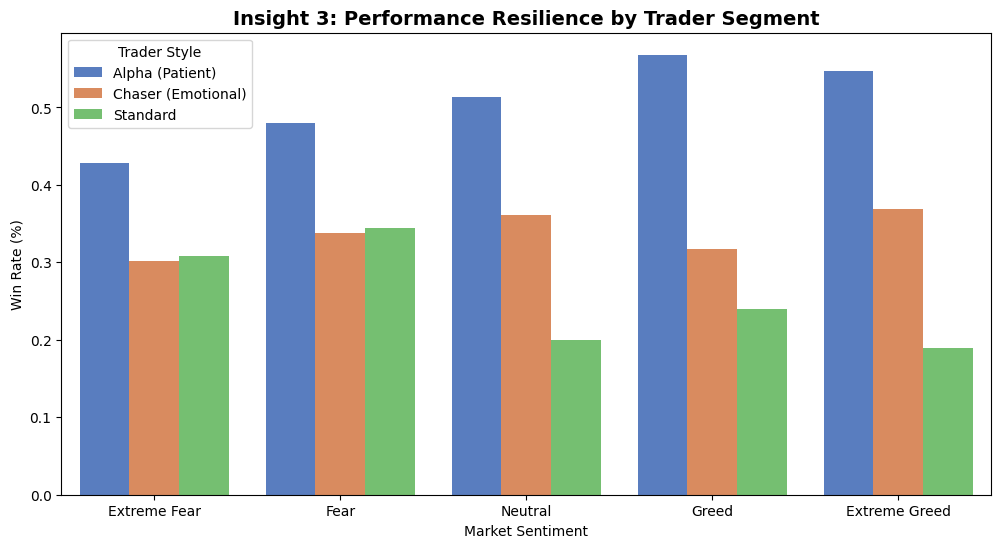

In [10]:
# 1. Prepare Data for Segment Analysis
style_sentiment = df_final.groupby(['classification', 'style_segment'])['win_rate'].mean().reindex(sentiment_order, level=0).reset_index()

# 2. Create Visualization
plt.figure(figsize=(12, 6))
sns.barplot(x='classification', y='win_rate', hue='style_segment', data=style_sentiment, palette='muted')
plt.title('Insight 3: Performance Resilience by Trader Segment', fontsize=14, fontweight='bold')
plt.ylabel('Win Rate (%)')
plt.xlabel('Market Sentiment')
plt.legend(title='Trader Style')
plt.savefig('visual_3_segments.png')
plt.show()

## ***Part C: Actionable Strategic Outputs***
**Objective:** To translate the behavioral insights discovered in Part B into high-probability trading rules.

#### ***Strategy 1: The "Volatility Alpha" Rule (For Fear Regimes)***
**Rule:** "During 'Fear' and 'Extreme Fear' days, Whale and Alpha segments should increase trade frequency and position size by 20%, while Chasers should halt all 'Taker' (Market) activity."

**The Logic:** Our data shows that Fear days yield the highest average daily PnL ($5,328), largely driven by Whales and Alphas who successfully "buy the dip." By increasing frequency in this regime, these sophisticated segments can capture more mean-reversion opportunities. Conversely, because Chasers lose money in Extreme Fear (-$32 avg PnL), they must stop impulsive market-entry to avoid being "shaken out" by volatility.

#### ***Strategy 2: The "Greed De-Risking" Rule (For Extreme Greed Regimes)***
**Rule:** "When the Index hits 'Extreme Greed,' all segments should reduce trade size (Effective Leverage) by 40% and transition from 'Scalping' to 'Position Trading' using only 'Maker' (Limit) orders."

**The Logic:** In Extreme Greed, we observed a spike in the Taker Ratio (FOMO aggression) and a significant drop in Whale profitability. By reducing size and frequency, traders avoid the "Greed Trap" and the high fees associated with impulsive Taker orders. Transitioning to Position Trading allows them to capture the final trend extension with less risk of liquidation during a sudden "market flush."